# Project 3 - Data Visualization
**Civil Engineering Analysis II | Spring 2026**

#### Project Designer: Arturo Garcia
#### Company: Peter Kiewit Institute
#### Client: Federal Highway Administration (FWHA)


In [62]:
#We should be able to import out packages here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('deep')

# NHTS Data Visualization

The NHTS provides insights as to how Americans use transportation. We shall explore household, vehicle types, and travel patterns.

In [63]:
#We are to load up the data here which has our survey
nhts_data = pd.read_csv('NHTS.csv')
nhts_data

,household_id,census_division,census_region,driver_count,household_income,household_size,household_workers,home_type,household_location,number_adults_household,...,urban,vehicle_type,hybrid,make,vehicle_age,vehicle_commercial,vehicle_delivery,vehicle_rideshare,fuel_type,vehicle_year
0,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,7,No,NaN,NaN,Gas,2015
1,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,3,No,NaN,NaN,Gas,2019
2,9000013016,New England,Northeast,2,"$75,000 to $99,999",2,2,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Toyota,11,No,NaN,NaN,Gas,2011
3,9000013039,New England,Northeast,2,"$75,000 to $99,999",4,1,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Nissan/Datsun,7,No,NaN,NaN,Gas,2015
4,9000013041,New England,Northeast,1,"$175,000 or more",1,1,"Townhome, Condo",Urban,1,...,In an urban area,Automobile/car/stationwagon,No,BMV,8,No,NaN,NaN,Gas,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14679,9000218013,East South Central,South,1,"$15,000 to $24,999",2,0,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Volkswagen,4,No,NaN,NaN,Gas,2018
14680,9000218021,East South Central,South,1,"$25,000 to $34,999",1,0,One-family detached,Rural,1,...,Not in an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Ford,6,Yes,No,No,Gas,2016
14681,9000218034,East South Central,South,2,"$25,000 to $34,999",2,0,One-family detached,Rural,2,...,Not in an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Honda,4,No,NaN,NaN,Gas,2018
14682,9000218034,East South Central,South,2,"$25,000 to $34,999",2,0,One-family detached,Rural,2,...,Not in an urban area,Pickup Truck,No,Toyota,19,No,NaN,NaN,Gas,2003


In [64]:
#We want to make a summary of our statistics as this should give us our count, mean, std, min, max
nhts_data.describe()

,household_id,driver_count,household_size,household_workers,number_adults_household,vehicles_per_household,travel_date,vehicle_age,vehicle_year
count,1.468400e+04,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000
mean,9.000113e+09,2.014165,2.558090,1.179447,2.061223,2.534323,202211.722623,10.174271,2011.866658
std,5.936829e+04,0.814926,1.333751,0.984043,0.812286,1.436046,20.578951,7.959353,8.009252
min,9.000013e+09,0.000000,1.000000,0.000000,1.000000,1.000000,202201.000000,1.000000,1982.000000
25%,9.000057e+09,2.000000,2.000000,0.000000,2.000000,2.000000,202204.000000,4.000000,2007.000000
50%,9.000107e+09,2.000000,2.000000,1.000000,2.000000,2.000000,202208.000000,8.000000,2014.000000
75%,9.000166e+09,2.000000,3.000000,2.000000,2.000000,3.000000,202211.000000,15.000000,2018.000000
max,9.000218e+09,7.000000,10.000000,6.000000,8.000000,17.000000,202301.000000,40.000000,2023.000000


In [65]:
# Use .value_counts() to see how many of each category are in the data
# This is useful for understanding categorical variables before plotting
nhts_data['make'].value_counts()
nhts_data['household_income'].value_counts()
nhts_data['travel_day'].value_counts()

travel_day
Monday       2698
Sunday       2589
Tuesday      2084
Friday       1977
Thursday     1943
Wednesday    1819
Saturday     1574
Name: count, dtype: int64

In [66]:
nhts_data.isnull().sum()

household_id                   0
census_division                0
census_region                  0
driver_count                   0
household_income               0
household_size                 0
household_workers              0
home_type                      0
household_location             0
number_adults_household        0
vehicles_per_household         0
travel_date                    0
travel_day                     0
urban                          0
vehicle_type                   0
hybrid                         0
make                         116
vehicle_age                    0
vehicle_commercial            39
vehicle_delivery           13491
vehicle_rideshare          13487
fuel_type                     32
vehicle_year                   0
dtype: int64

## Countplot

Before diving into more complex plots, let’s start with something simple, a countplot! A countplot shows how many observations exist in each category. This is one of the simplest but most useful plots to understand your data.

Let’s see how many vehicles of each type are in our dataset.

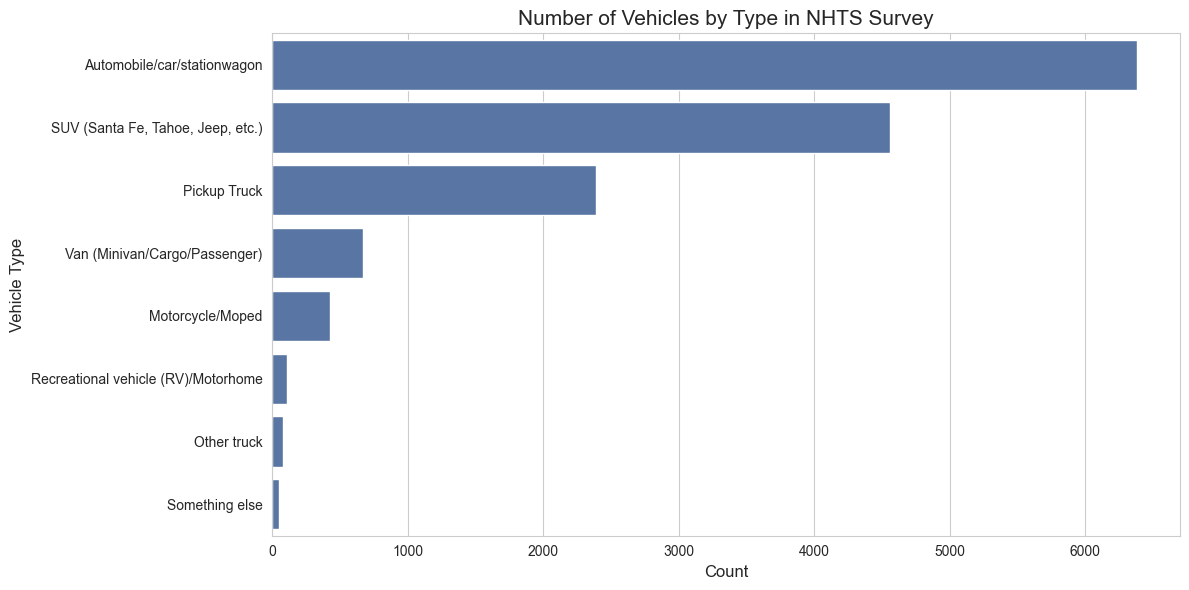

In [67]:
plt.figure(figsize = (12, 6))
sns.countplot(data = nhts_data, y = 'vehicle_type', order = nhts_data['vehicle_type'].value_counts().index)
plt.xlabel('Count', fontsize = 12)
plt.ylabel('Vehicle Type', fontsize = 12)
plt.title('Number of Vehicles by Type in NHTS Survey', fontsize = 15)
plt.tight_layout()
plt.show()

## Histogram

Histograms are graphs that also show the distribution of data, but only show the distribution of a single, continuous variable. Like boxplots, Python knows what histograms are, so if you give Python the variable you want to plot, Python knows to create ‘bins’ for the data and then count how many observations are in those bins. Note: Python will have a default number of bins based on your data size and shape, but you can change this if you want to see a specific breakdown of your data. Let’s look at a histogram of `vehicle_age`.

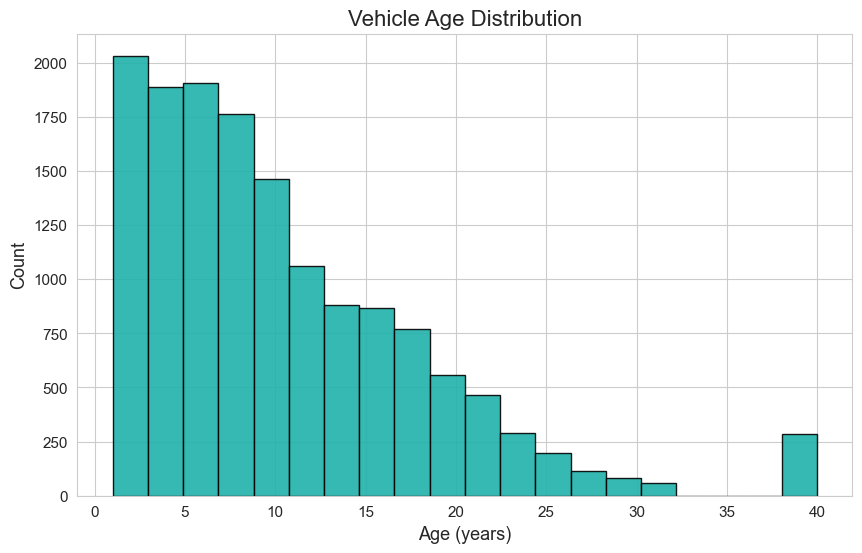

In [68]:
plt.figure(figsize = (10,6))

plt.hist(nhts_data['vehicle_age'], bins = 20, color = 'lightseagreen', edgecolor = 'black', alpha = 0.9)

plt.title('Vehicle Age Distribution', fontsize = 16)
plt.xlabel('Age (years)', fontsize = 13)
plt.ylabel('Count', fontsize = 13)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.show()

Now let’s try something more advanced — overlaying histograms for different groups. Let’s compare vehicle age distribution between Urban and Rural households on the same plot!

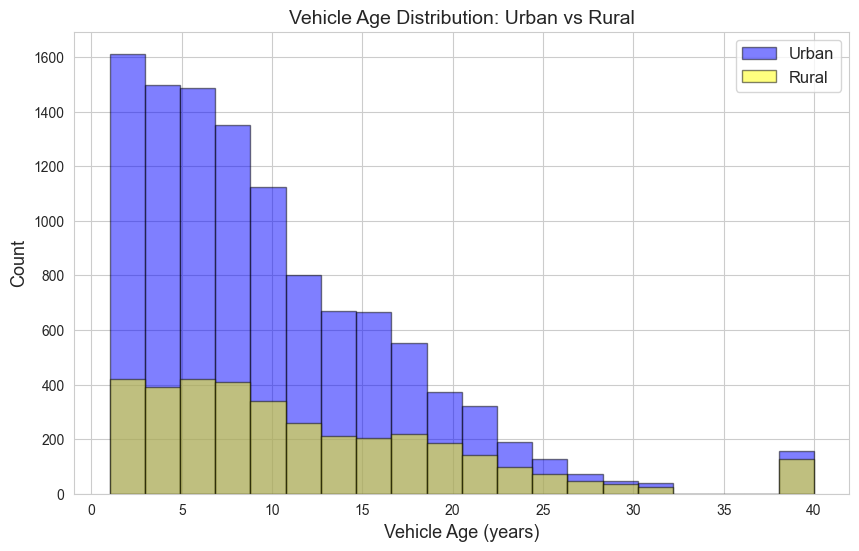

In [69]:
plt.figure(figsize = (10,6))

# use the alpha argument to make bars semi-transparent (e.g., alpha=0.5)
urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
plt.hist(urban_ages, bins = 20, alpha = 0.5, label = 'Urban', color = 'blue', edgecolor = 'black')

rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_age']
plt.hist(rural_ages, bins = 20, alpha = 0.5, label = 'Rural', color = 'yellow', edgecolor = 'black')

plt.xlabel('Vehicle Age (years)', fontsize = 13)
plt.ylabel('Count', fontsize = 13)
plt.title('Vehicle Age Distribution: Urban vs Rural', fontsize = 14)
plt.legend(fontsize = 12)
plt.show()

## Boxplot

Boxplots show the distribution of one variable, including the median (50th percentile) and the 25th and 75th percentiles. On a boxplot, the middle of the box is bisected with a line, representing the median. The top edge of the box is the 75th percentile and the bottom edge of the box is the 25th percentile. The whiskers (lines) that extend from the box show the top and bottom range of the data. The individual dots beyond the whiskers are outliers.

In Python (and many other coding languages), packages like matplotlib have built in functions that understand how to construct boxplots. As a result, you need to choose a variable to plot.

Note, you need one variable to be continuous, not discrete! Let’s try making a boxplot of vehicle ages by vehicle make.

<Figure size 1400x600 with 0 Axes>

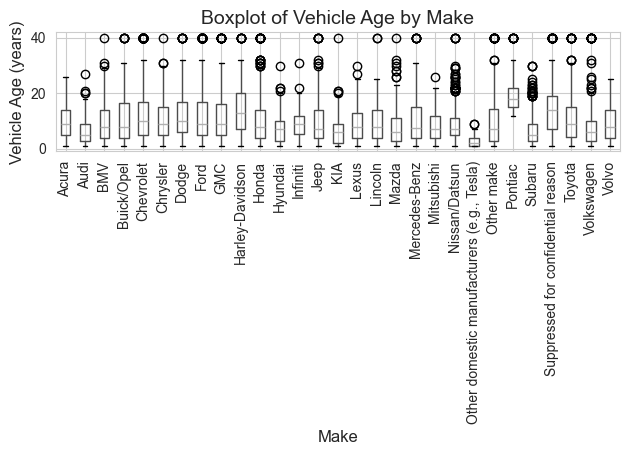

In [70]:
plt.figure(figsize = (14,6))

boxplot = nhts_data.boxplot(column = 'vehicle_age', by = 'make', rot = 90)

plt.xticks(rotation=90)

plt.xlabel('Make', fontsize = 12)
plt.ylabel('Vehicle Age (years)', fontsize = 12)
### this line gives your plot a title
plt.title('Boxplot of Vehicle Age by Make', fontsize = 14)
plt.suptitle('')

plt.tight_layout()
plt.show()

## Violin Plot

A violin plot is similar to a boxplot, but it also shows the full distribution shape of the data using a kernel density estimate (KDE). The wider the violin, the more data points exist at that value. This gives us more information than a boxplot alone.

Let’s compare vehicle ages for Urban vs Rural households using a violin plot.

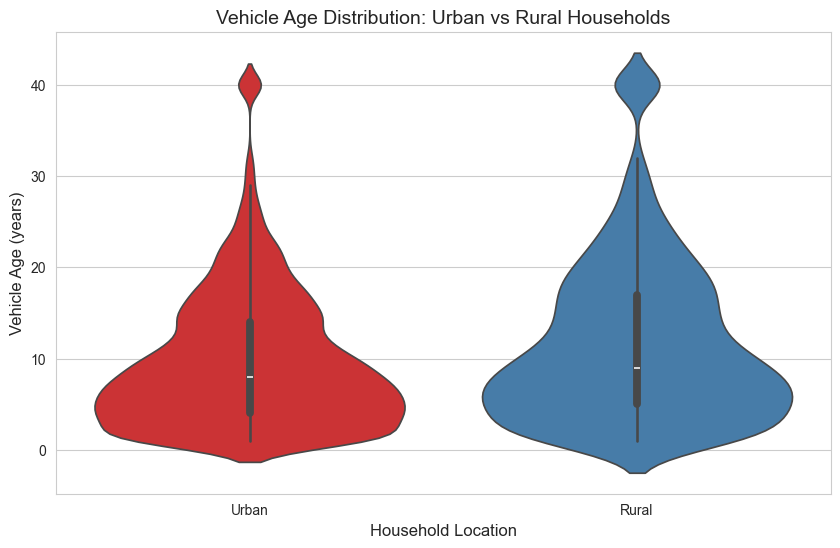

In [71]:
plt.figure(figsize = (10, 6))

sns.violinplot(data = nhts_data, x = 'household_location', y = 'vehicle_age', hue = 'household_location', palette = 'Set1')

plt.xlabel('Household Location', fontsize = 12)
plt.ylabel('Vehicle Age (years)', fontsize = 12)
plt.title('Vehicle Age Distribution: Urban vs Rural Households', fontsize =14)

plt.show()

# NGSIM Time Series Data Visualization

Next Generation Simulation (NGSIM) data (https://ops.fhwa.dot.gov/trafficanalysistools/ngsim.htm) is one of the most influential datasets collected and released by the U.S. Department of Transportation - Federal Highway Administration. The goal of this data is to "To develop a core of open behavioral algorithms in support of traffic simulation with a primary focus on microscopic modeling, including supporting documentation and validation data sets that describe the interactions of multimodal travelers, vehicles and highway systems, and interactions presented to them from traffic control devices, delineation, congestion, and other features of the environment."

Much of what we know now about driving behavior comes from this dataset. This has a huge impact on the way we design, manage, and operate our transportation system.

In [72]:
ngsim_data = pd.read_csv('NGSIM.csv')

ngsim_data.head(10)

,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
0,0.1,26.654,0.0000,14.054,14.484,1.097300e+00,-3.048000e-02,1
1,0.2,28.060,1.4484,14.164,14.481,-1.005800e+00,-3.048000e-02,1
2,0.3,29.476,2.8965,14.063,14.478,-2.286000e+00,6.096000e-02,1
3,0.4,30.882,4.3443,13.835,14.484,-8.839200e-01,-3.048000e-02,1
4,0.5,32.266,5.7927,13.746,14.481,8.534400e-01,1.780000e-13,1
5,0.6,33.640,7.2408,13.832,14.481,2.164100e+00,3.657600e-01,1
6,0.7,35.024,8.6889,14.048,14.518,1.005800e+00,-7.315200e-01,1
7,0.8,36.428,10.1410,14.149,14.444,-5.181600e-01,-1.432600e+00,1
8,0.9,37.843,11.5850,14.097,14.301,-7.110000e-13,-5.791200e-01,1
9,1.0,39.253,13.0150,14.097,14.243,0.000000e+00,5.486400e-01,1


In [73]:
print("Columns in dataset:", ngsim_data.columns)
print("Dataset info:")
print(ngsim_data.info())

Columns in dataset: Index(['Time', 'leader_position(m)', 'follower_position(m)',
       'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)',
       'follower_acc(m/s^2)', 'trajectory_number'],
      dtype='object')
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8166 entries, 0 to 8165
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time                  8166 non-null   float64
 1   leader_position(m)    8166 non-null   float64
 2   follower_position(m)  8166 non-null   float64
 3   leader_speed(m/s)     8166 non-null   float64
 4   follower_speed(m/s)   8166 non-null   float64
 5   leader_acc(m/s^2)     8166 non-null   float64
 6   follower_acc(m/s^2)   8166 non-null   float64
 7   trajectory_number     8166 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 510.5 KB
None


## Exploring the Data Numerically

Before there is anything to plot, we can use statistics to understand the range and distribution of values in our dataset. This will help us interpret the graphs. 

In [74]:
ngsim_data.describe()

,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
count,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000
mean,27.929611,266.263343,246.576350,8.745533,8.776852,-0.059325,-0.035836,8.176708
std,19.131202,135.110878,134.904708,3.695903,3.784383,1.666269,1.765766,4.811499
min,0.100000,8.227800,0.000000,0.000000,0.000000,-15.240000,-15.240000,1.000000
25%,12.800000,161.337500,141.870000,6.096000,6.096000,-0.365760,-0.365760,4.000000
50%,25.600000,254.180000,237.925000,9.121150,9.128800,0.000000,0.000000,8.000000
75%,38.300000,365.700000,344.990000,12.064000,12.133250,0.335280,0.365760,13.000000
max,84.100000,651.500000,619.050000,17.221000,17.898000,8.046700,15.240000,16.000000


In [75]:
print(ngsim_data['trajectory_number'].nunique())
print(ngsim_data.groupby('trajectory_number').size())

16
trajectory_number
1     841
2     398
3     483
4     826
5     401
6     438
7     506
8     394
9     401
10    432
11    447
12    419
13    802
14    448
15    398
16    532
dtype: int64


## Plotting the Acceleration vs Time

Time series data is a sequence of data points recorded at successive time intervals. Plotting time series data means plotting some variable against a time attribute. In transportation studies, time series data helps us understand vehicle movement and behavior.

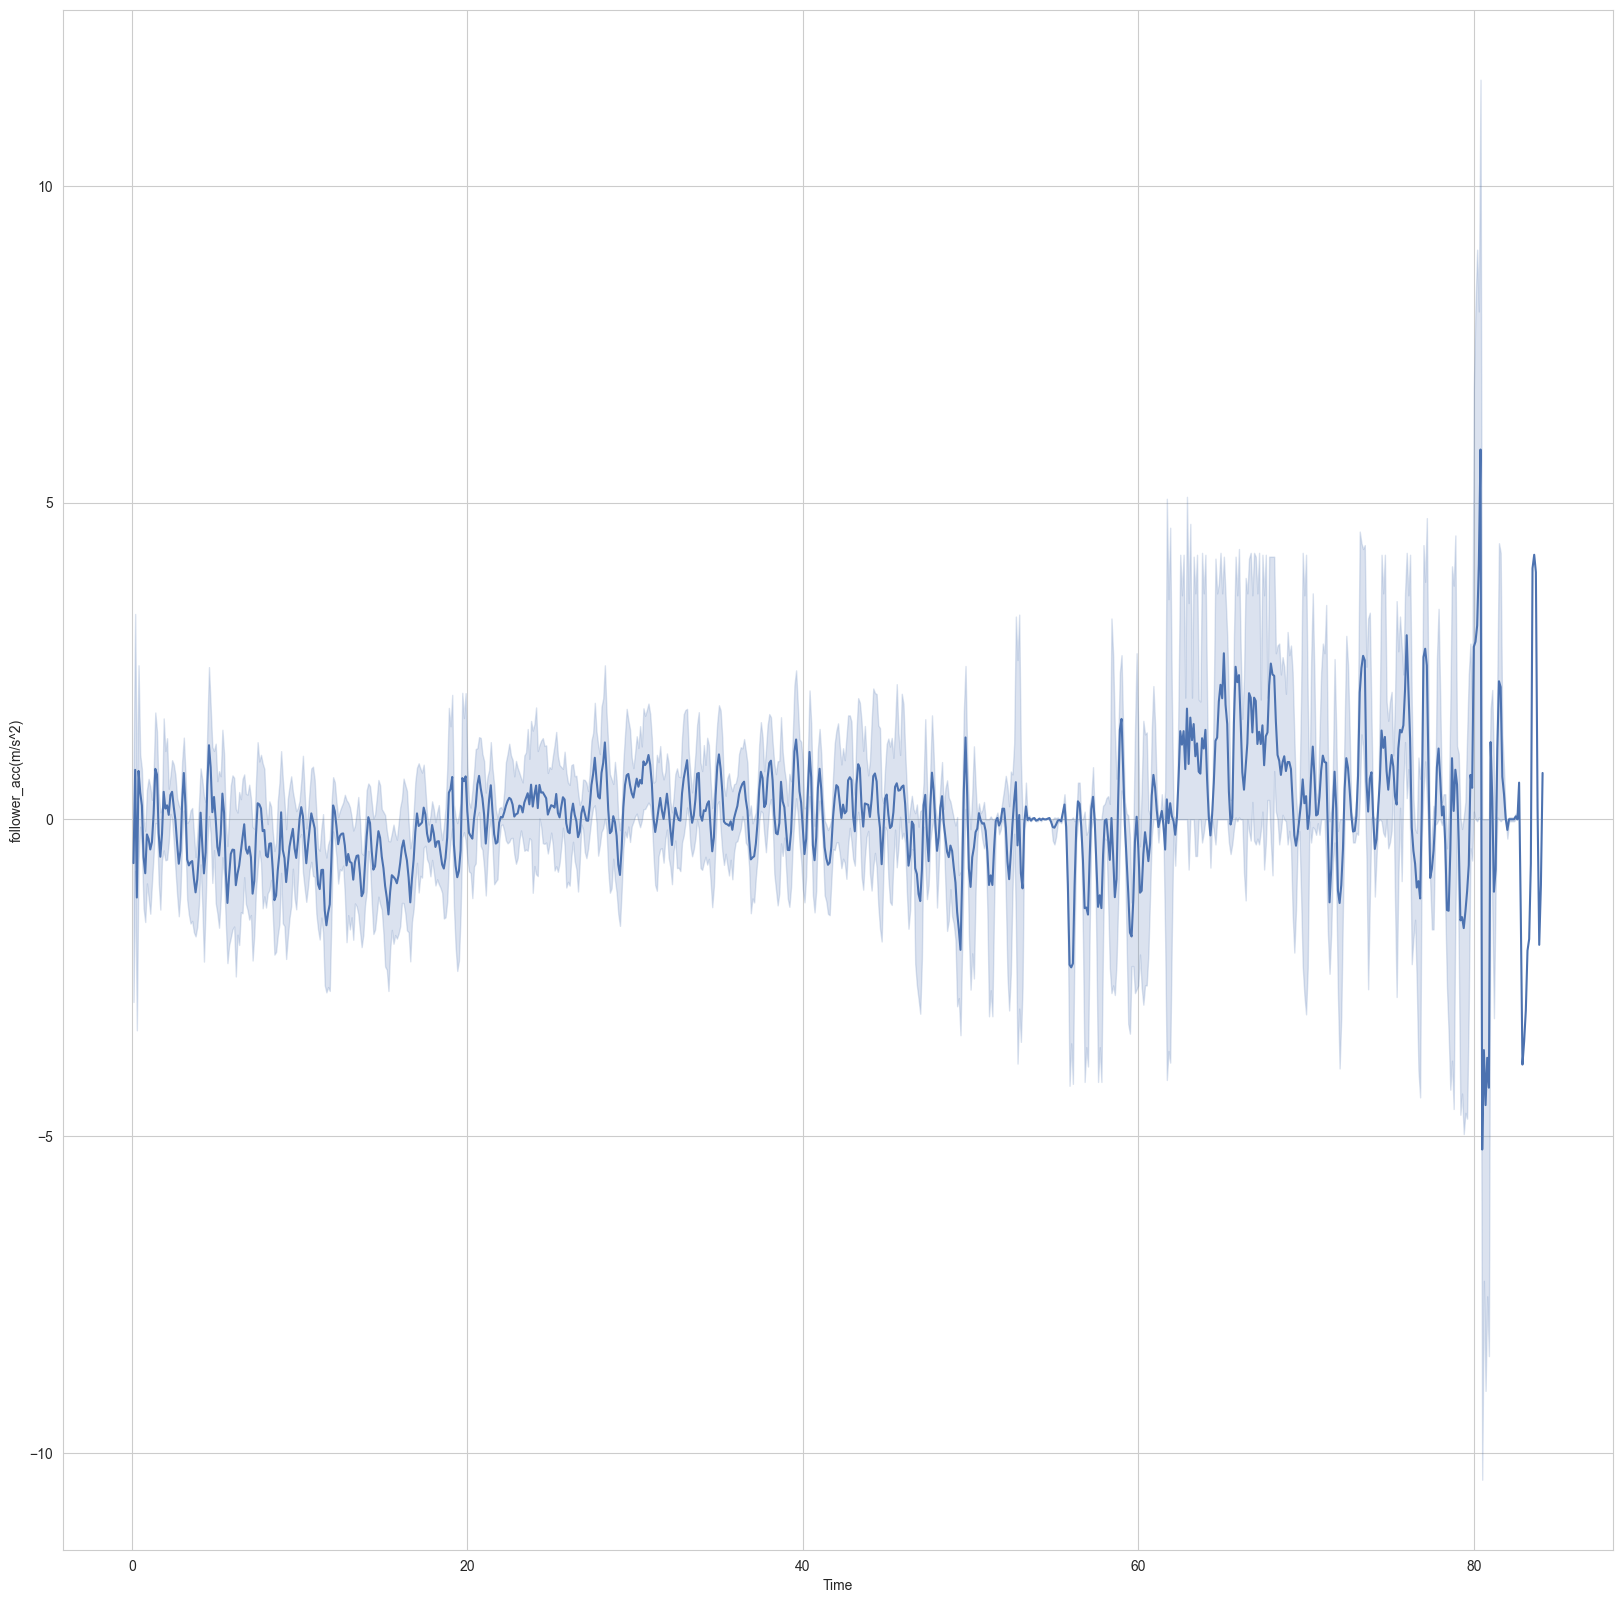

In [80]:
plt.figure(figsize = (20,20))

sns.lineplot(x = ngsim_data['Time'], y=ngsim_data['follower_acc(m/s^2)'])

plt.show()

## Plotting Speed vs Time

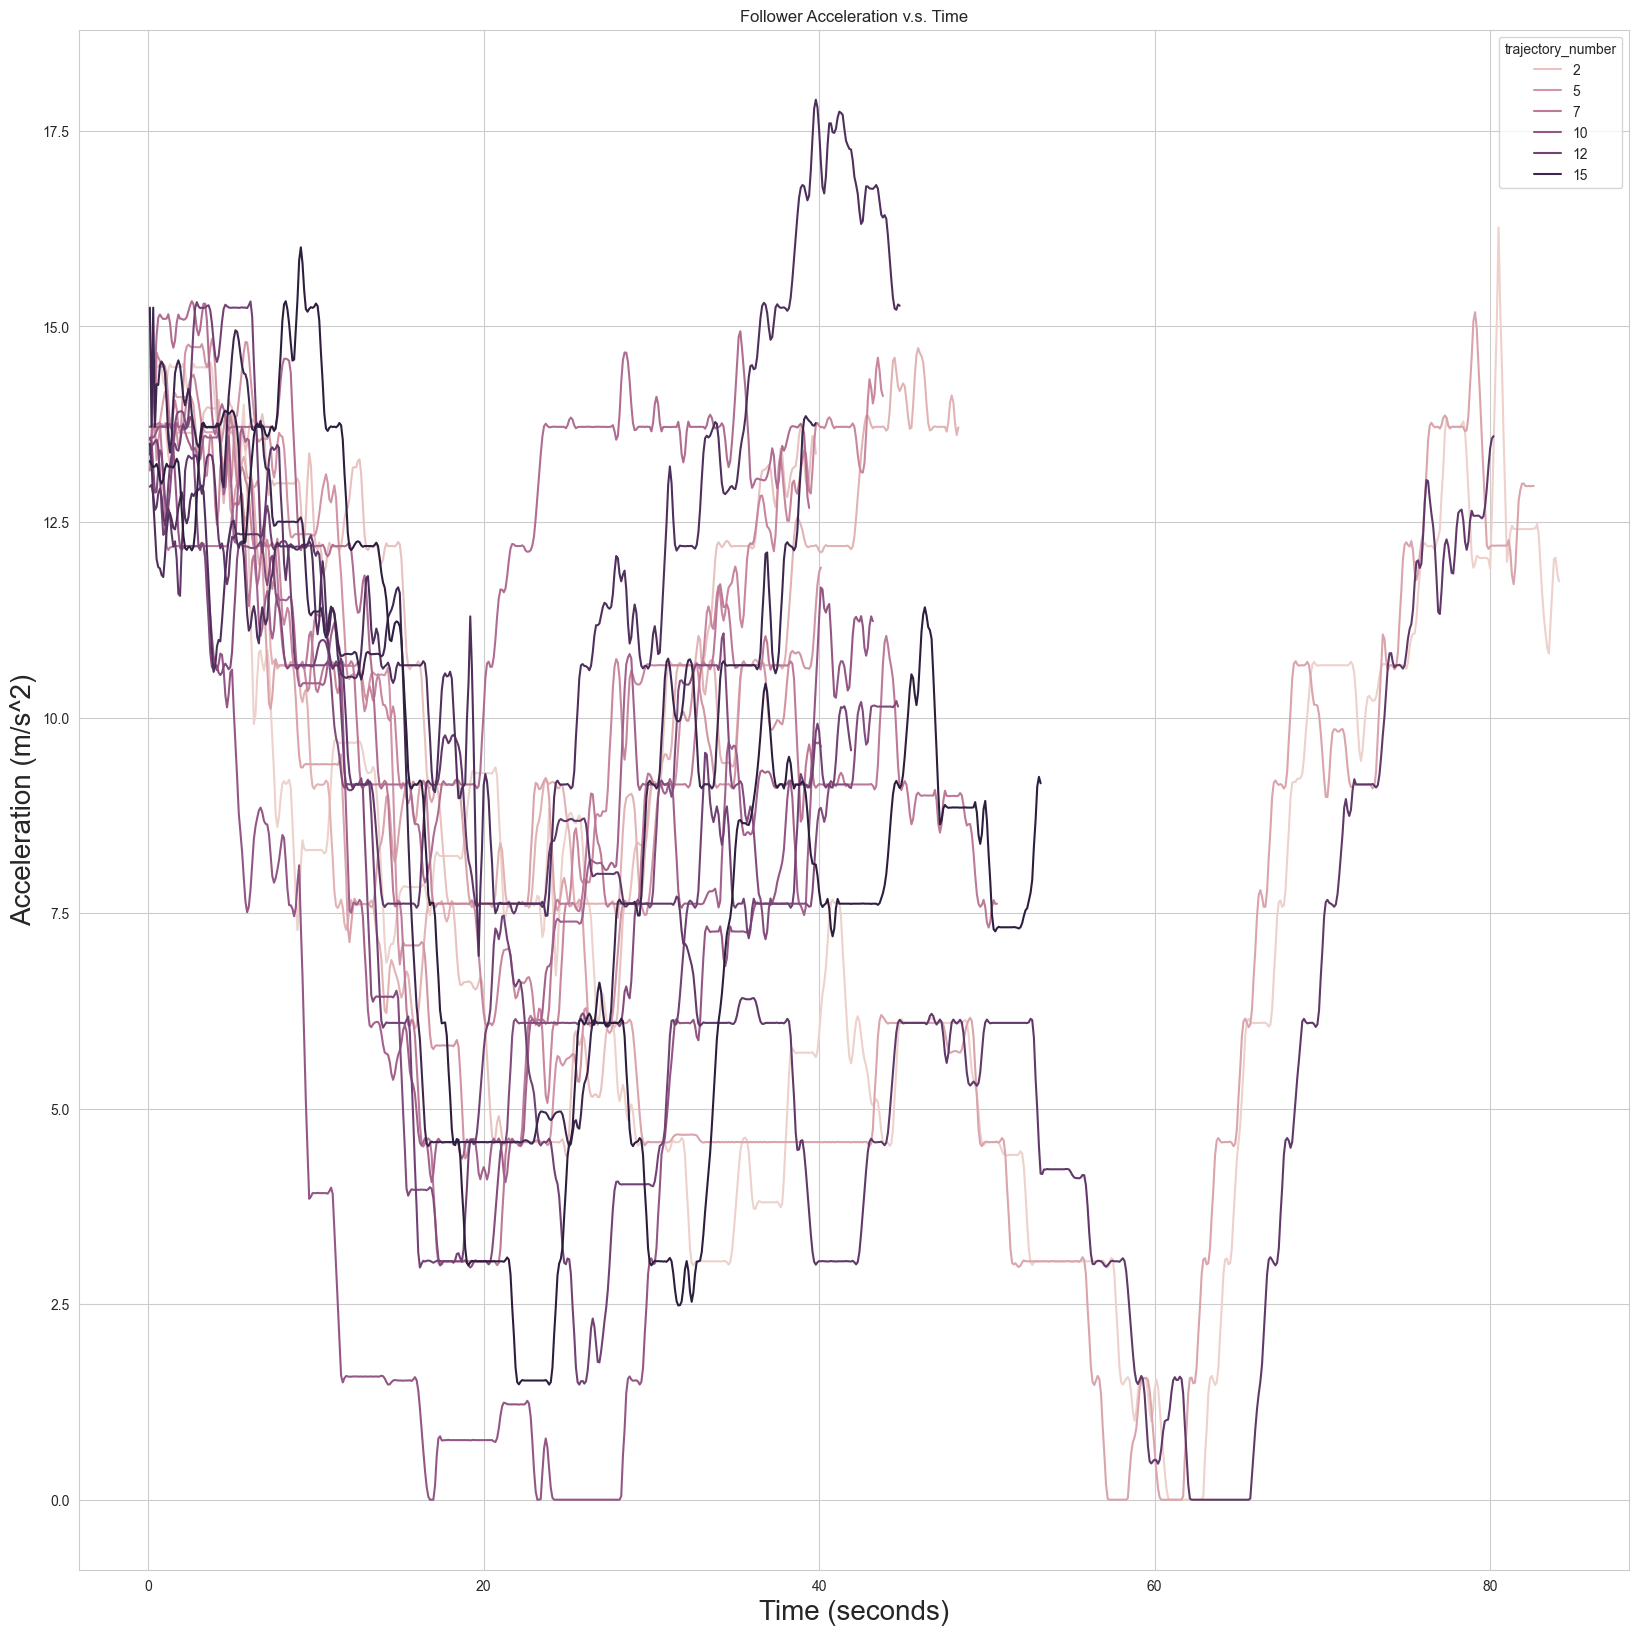

In [77]:
plt.figure(figsize = (20,20))

sns.lineplot(x = ngsim_data['Time'], y=ngsim_data['follower_speed(m/s)'],
             hue = ngsim_data['trajectory_number'])

plt.xlabel('Time (seconds)', fontsize = 20)
plt.ylabel('Acceleration (m/s^2)', fontsize = 20)
plt.title('Follower Acceleration v.s. Time')

plt.show()

## Position vs Time

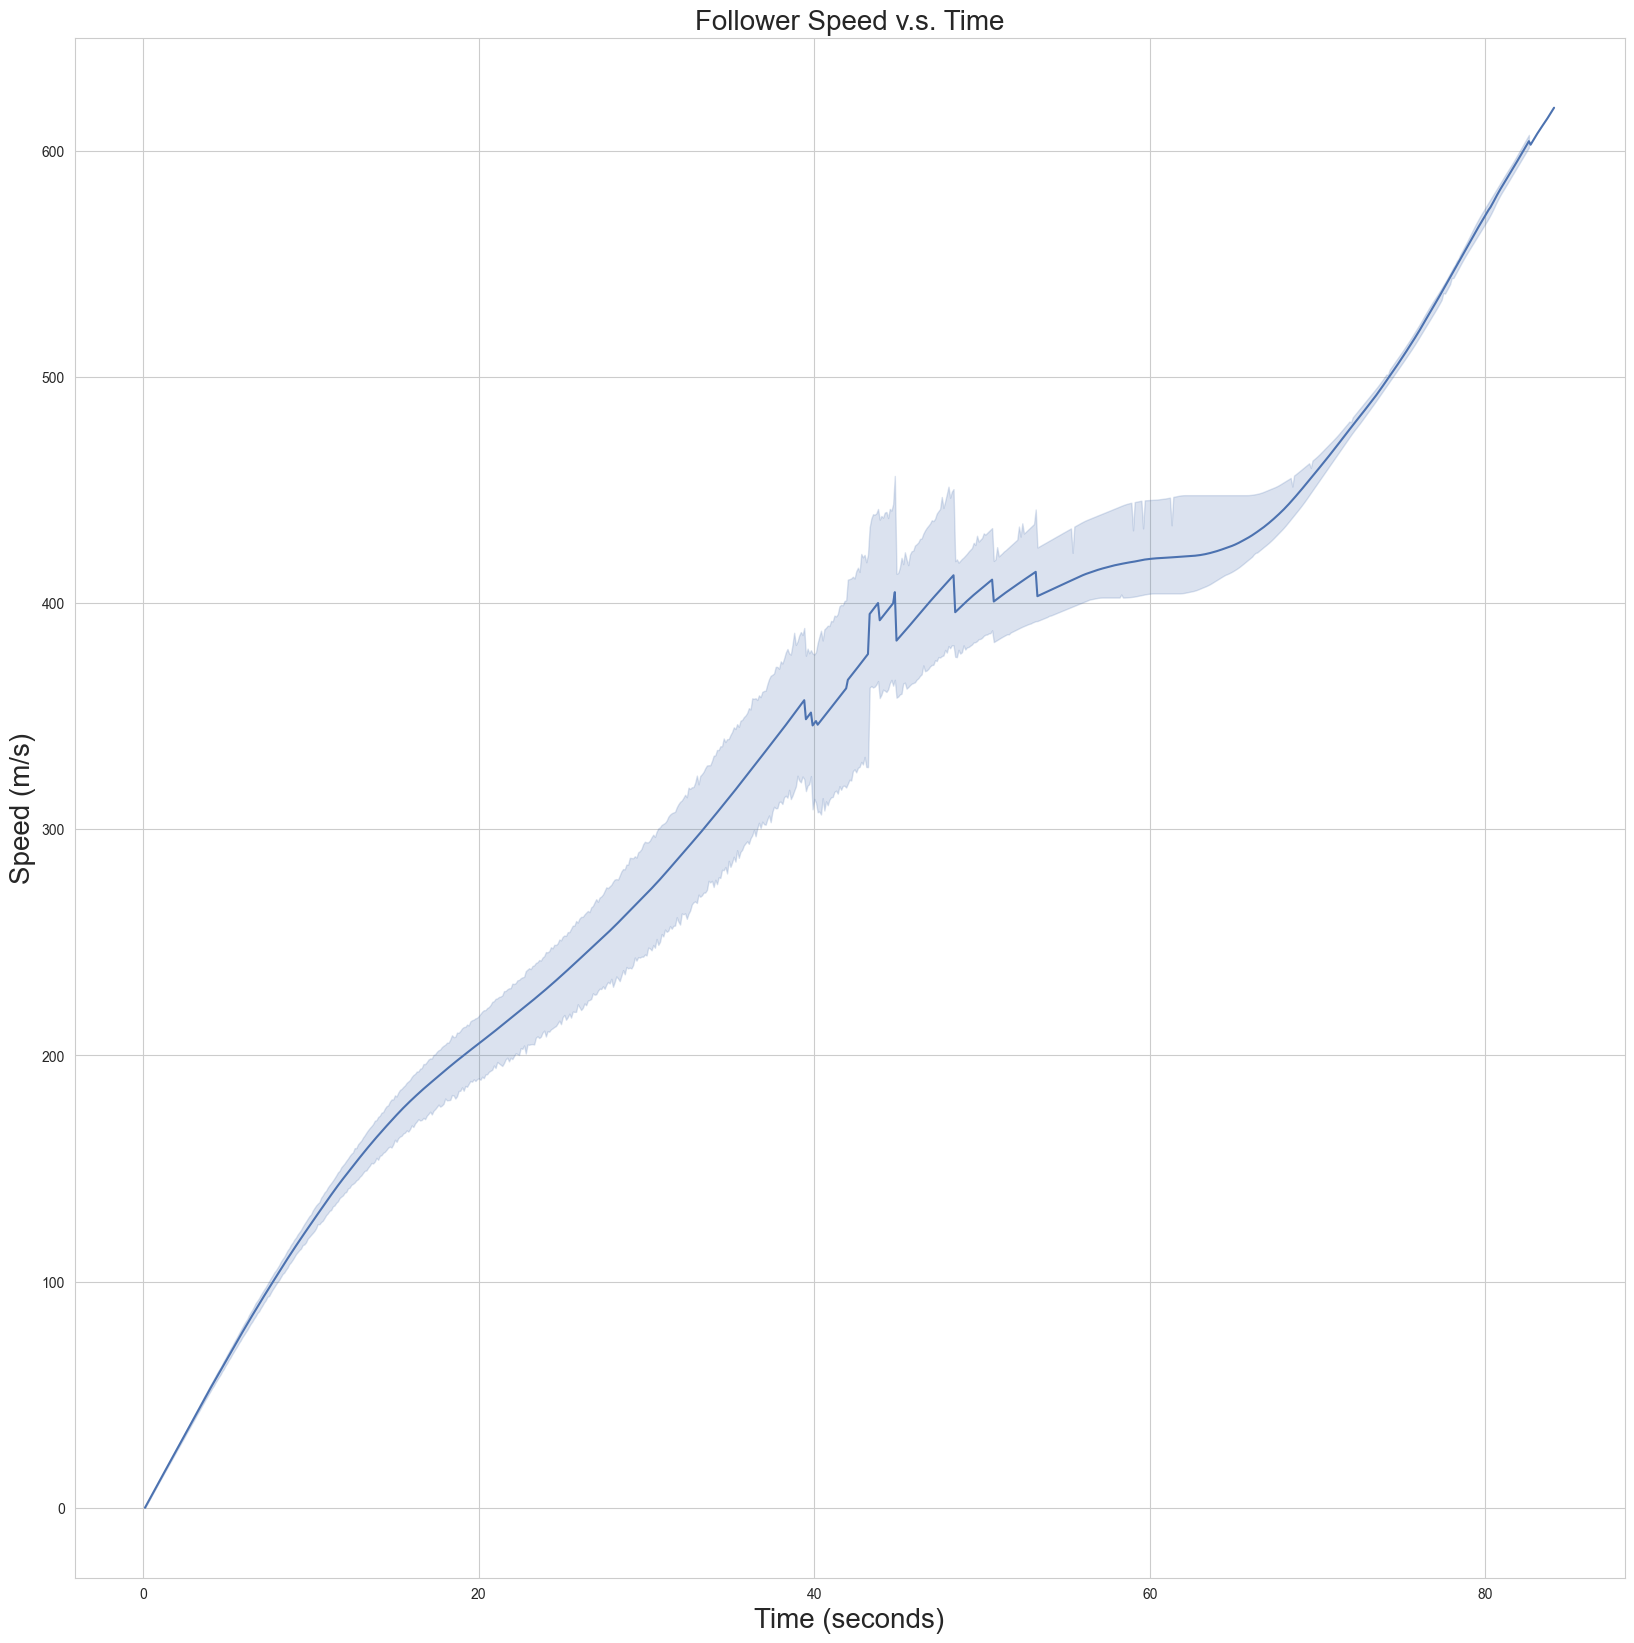

In [78]:
plt.figure(figsize = (20,20))

sns.lineplot(x = ngsim_data['Time'], y=ngsim_data['follower_position(m)'])

plt.xlabel('Time (seconds)', fontsize = 20)
plt.ylabel('Speed (m/s)', fontsize = 20)
plt.title('Follower Speed v.s. Time', fontsize = 20)
plt.show()

## Follower and Leader Position vs Time

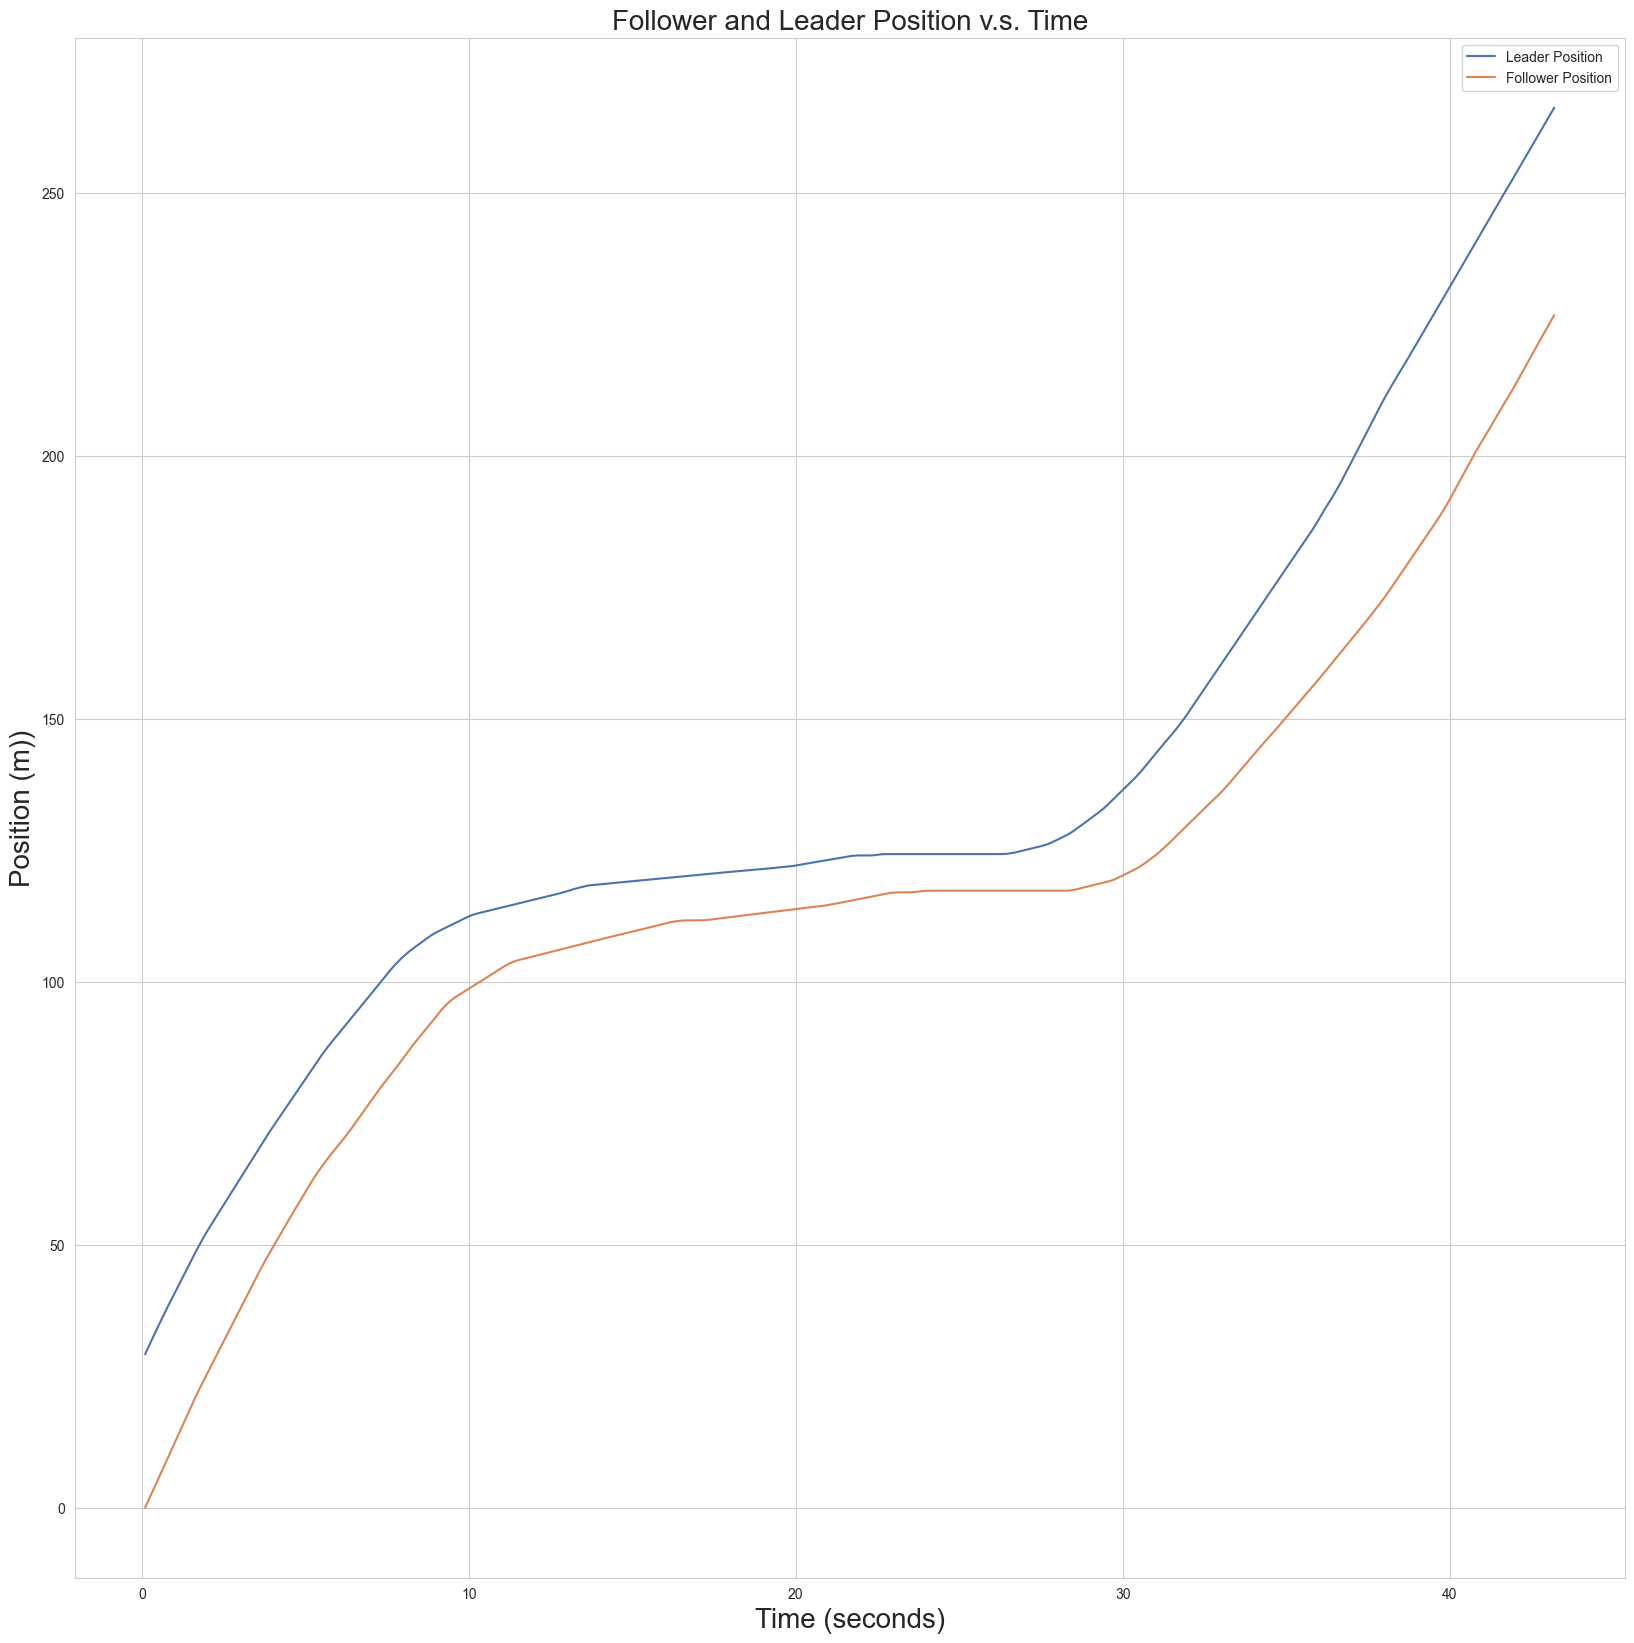

In [37]:
trajectory_number = 10

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

plt.figure(figsize = (20,20))
sns.lineplot(data = data_subset, x = 'Time', y = 'leader_position(m)', label='Leader Position')
sns.lineplot(data = data_subset, x = 'Time', y = 'follower_position(m)', label='Follower Position')

plt.xlabel('Time (seconds)', fontsize = 20)
plt.ylabel('Position (m))', fontsize = 20)
plt.title('Follower and Leader Position v.s. Time', fontsize = 20)
plt.show()

## Follower and Leader Speed vs Time

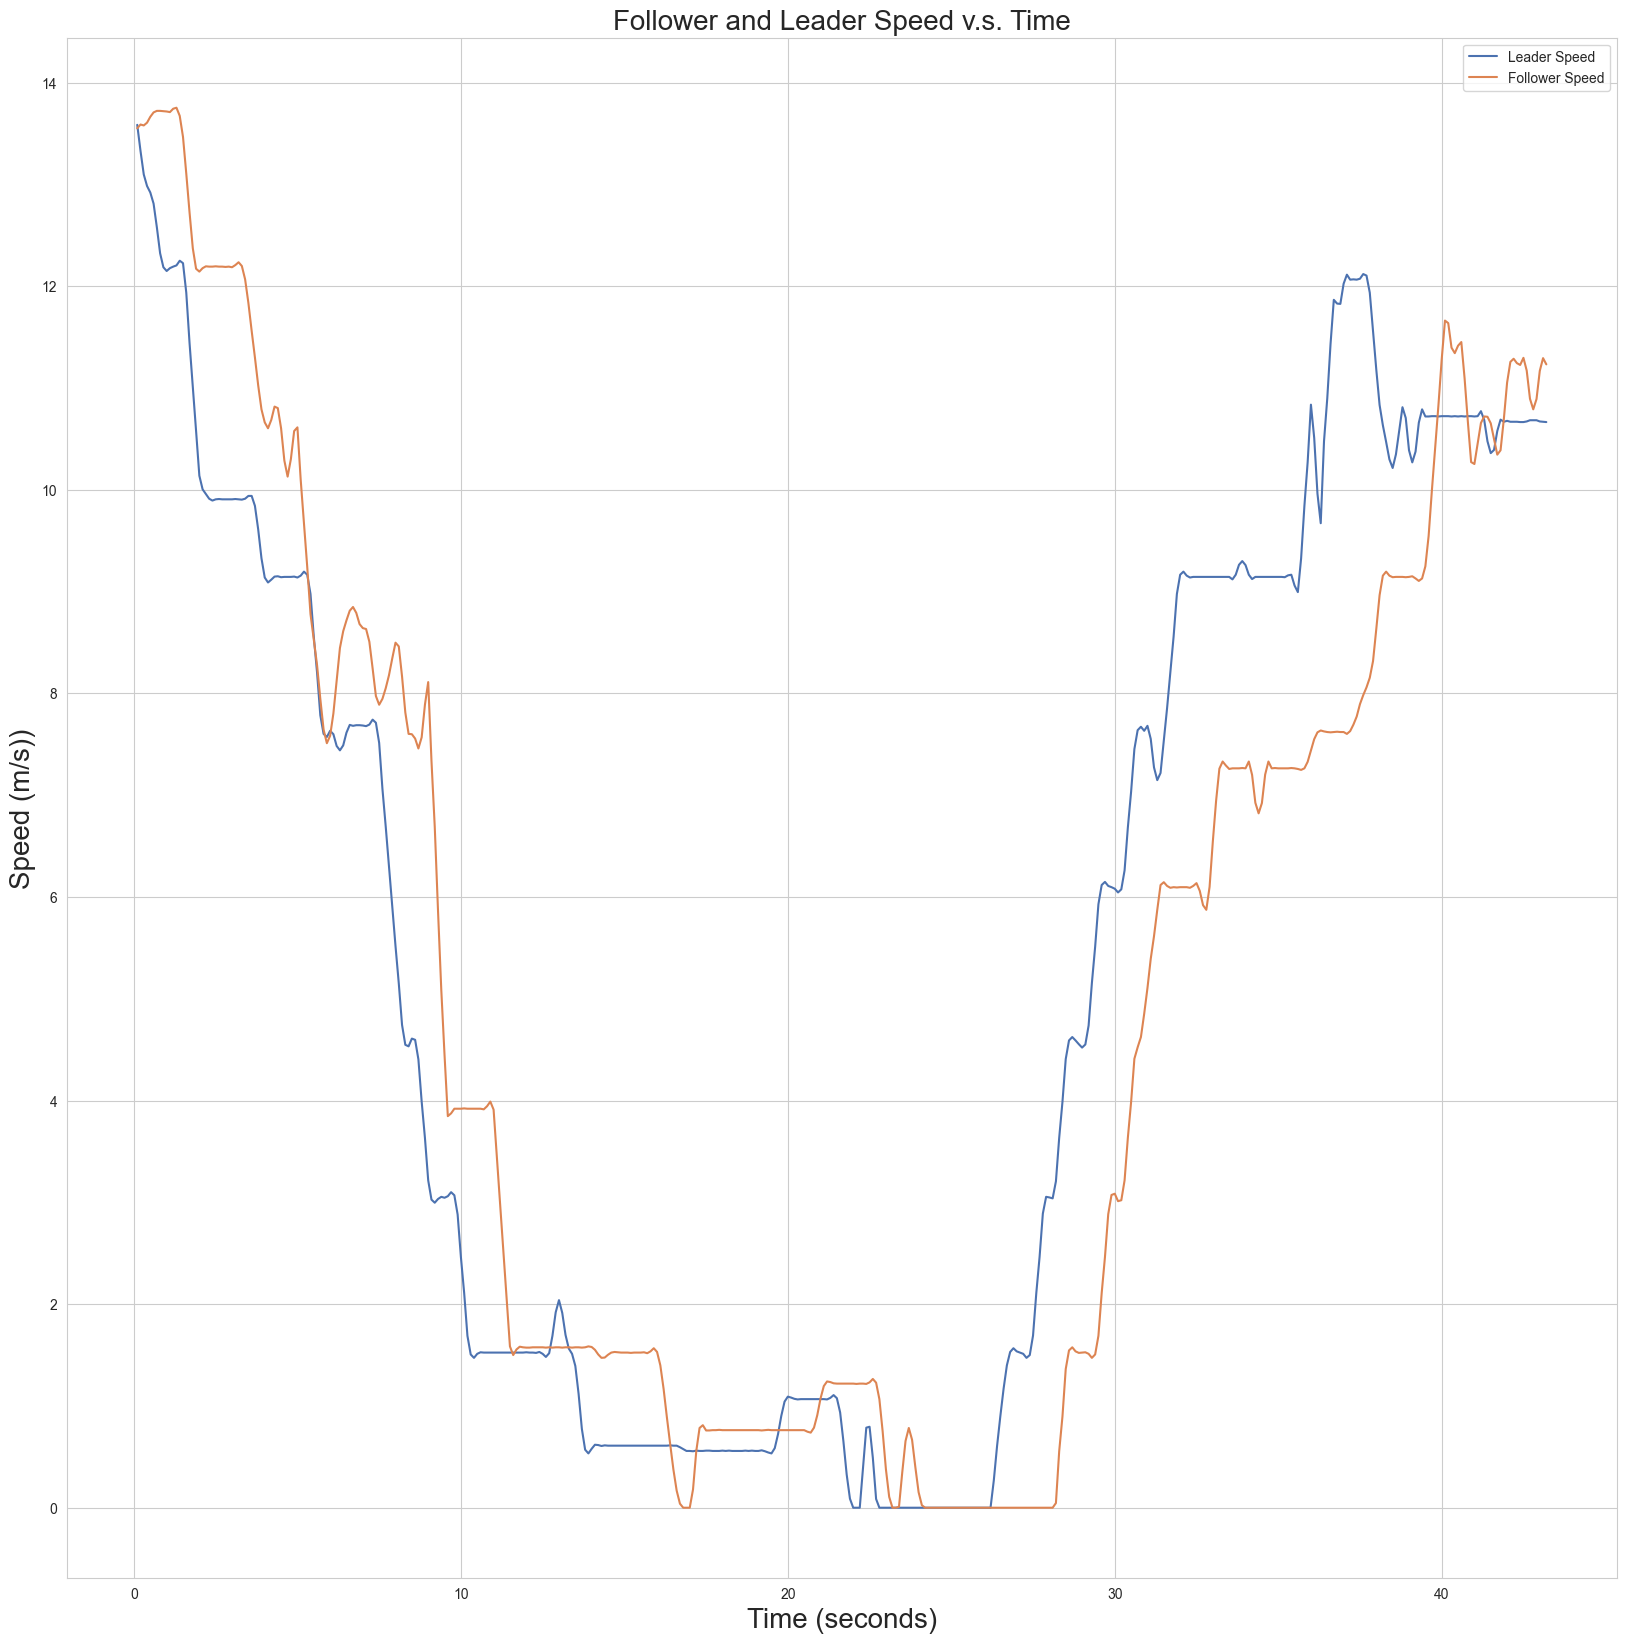

In [42]:
trajectory_number = 10

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

plt.figure(figsize = (20,20))
sns.lineplot(data = data_subset, x = 'Time', y = 'leader_speed(m/s)', label='Leader Speed')
sns.lineplot(data = data_subset, x = 'Time', y = 'follower_speed(m/s)', label='Follower Speed')

plt.xlabel('Time (seconds)', fontsize = 20)
plt.ylabel('Speed (m/s))', fontsize = 20)
plt.title('Follower and Leader Speed v.s. Time', fontsize = 20)
plt.show()

## Follower and Leader Acceleration vs Time

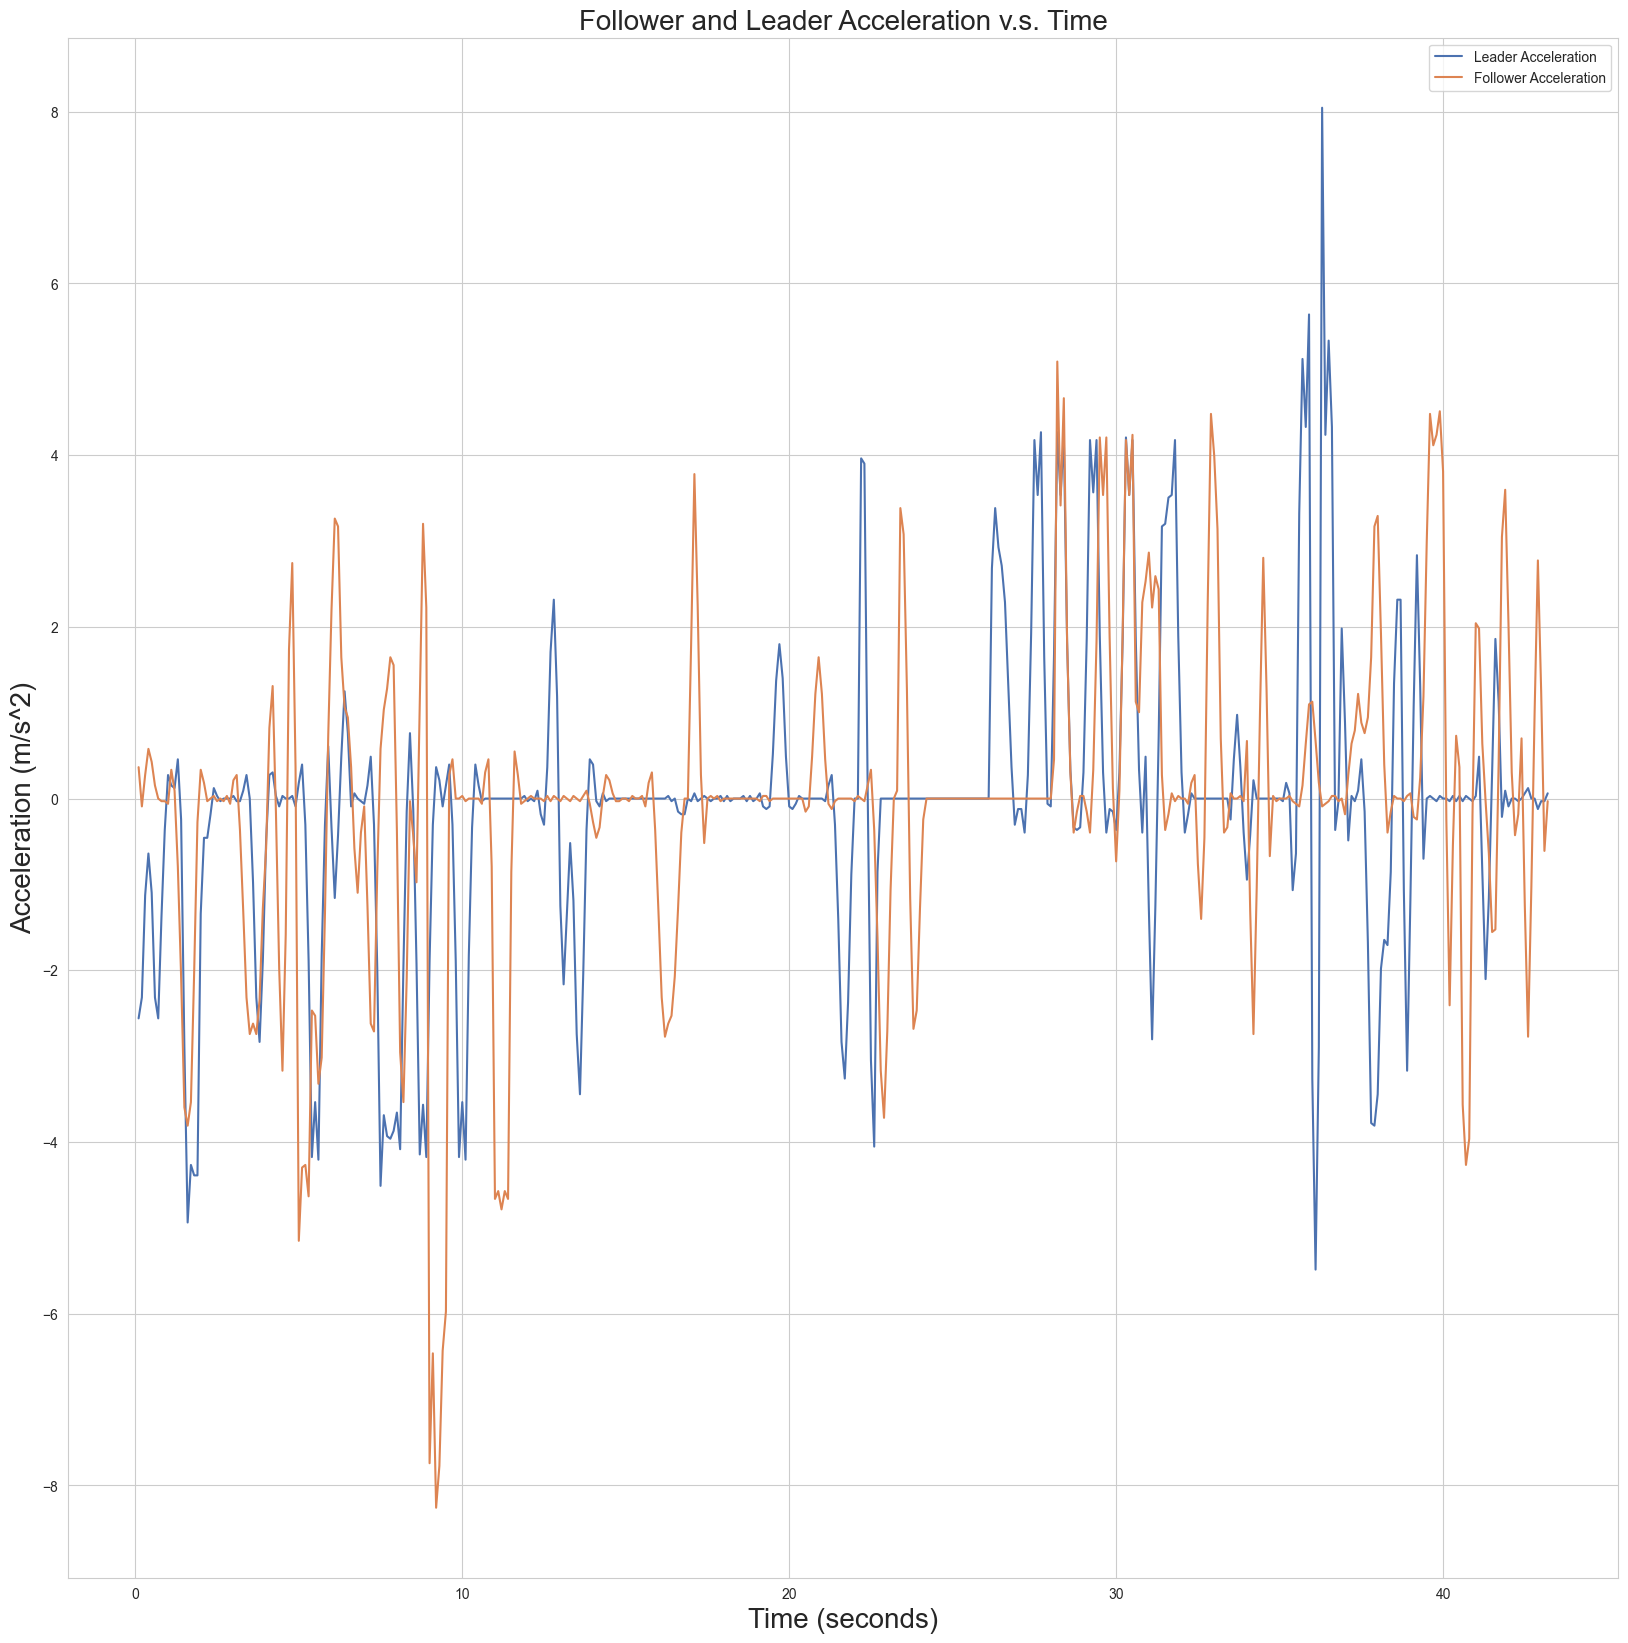

In [44]:
trajectory_number = 10

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

plt.figure(figsize = (20,20))
sns.lineplot(data = data_subset, x = 'Time', y = 'leader_acc(m/s^2)', label='Leader Acceleration')
sns.lineplot(data = data_subset, x = 'Time', y = 'follower_acc(m/s^2)', label='Follower Acceleration')

plt.xlabel('Time (seconds)', fontsize = 20)
plt.ylabel('Acceleration (m/s^2)', fontsize = 20)
plt.title('Follower and Leader Acceleration v.s. Time', fontsize = 20)
plt.show()

## Gap Distance Between Leader and Follower Over Time

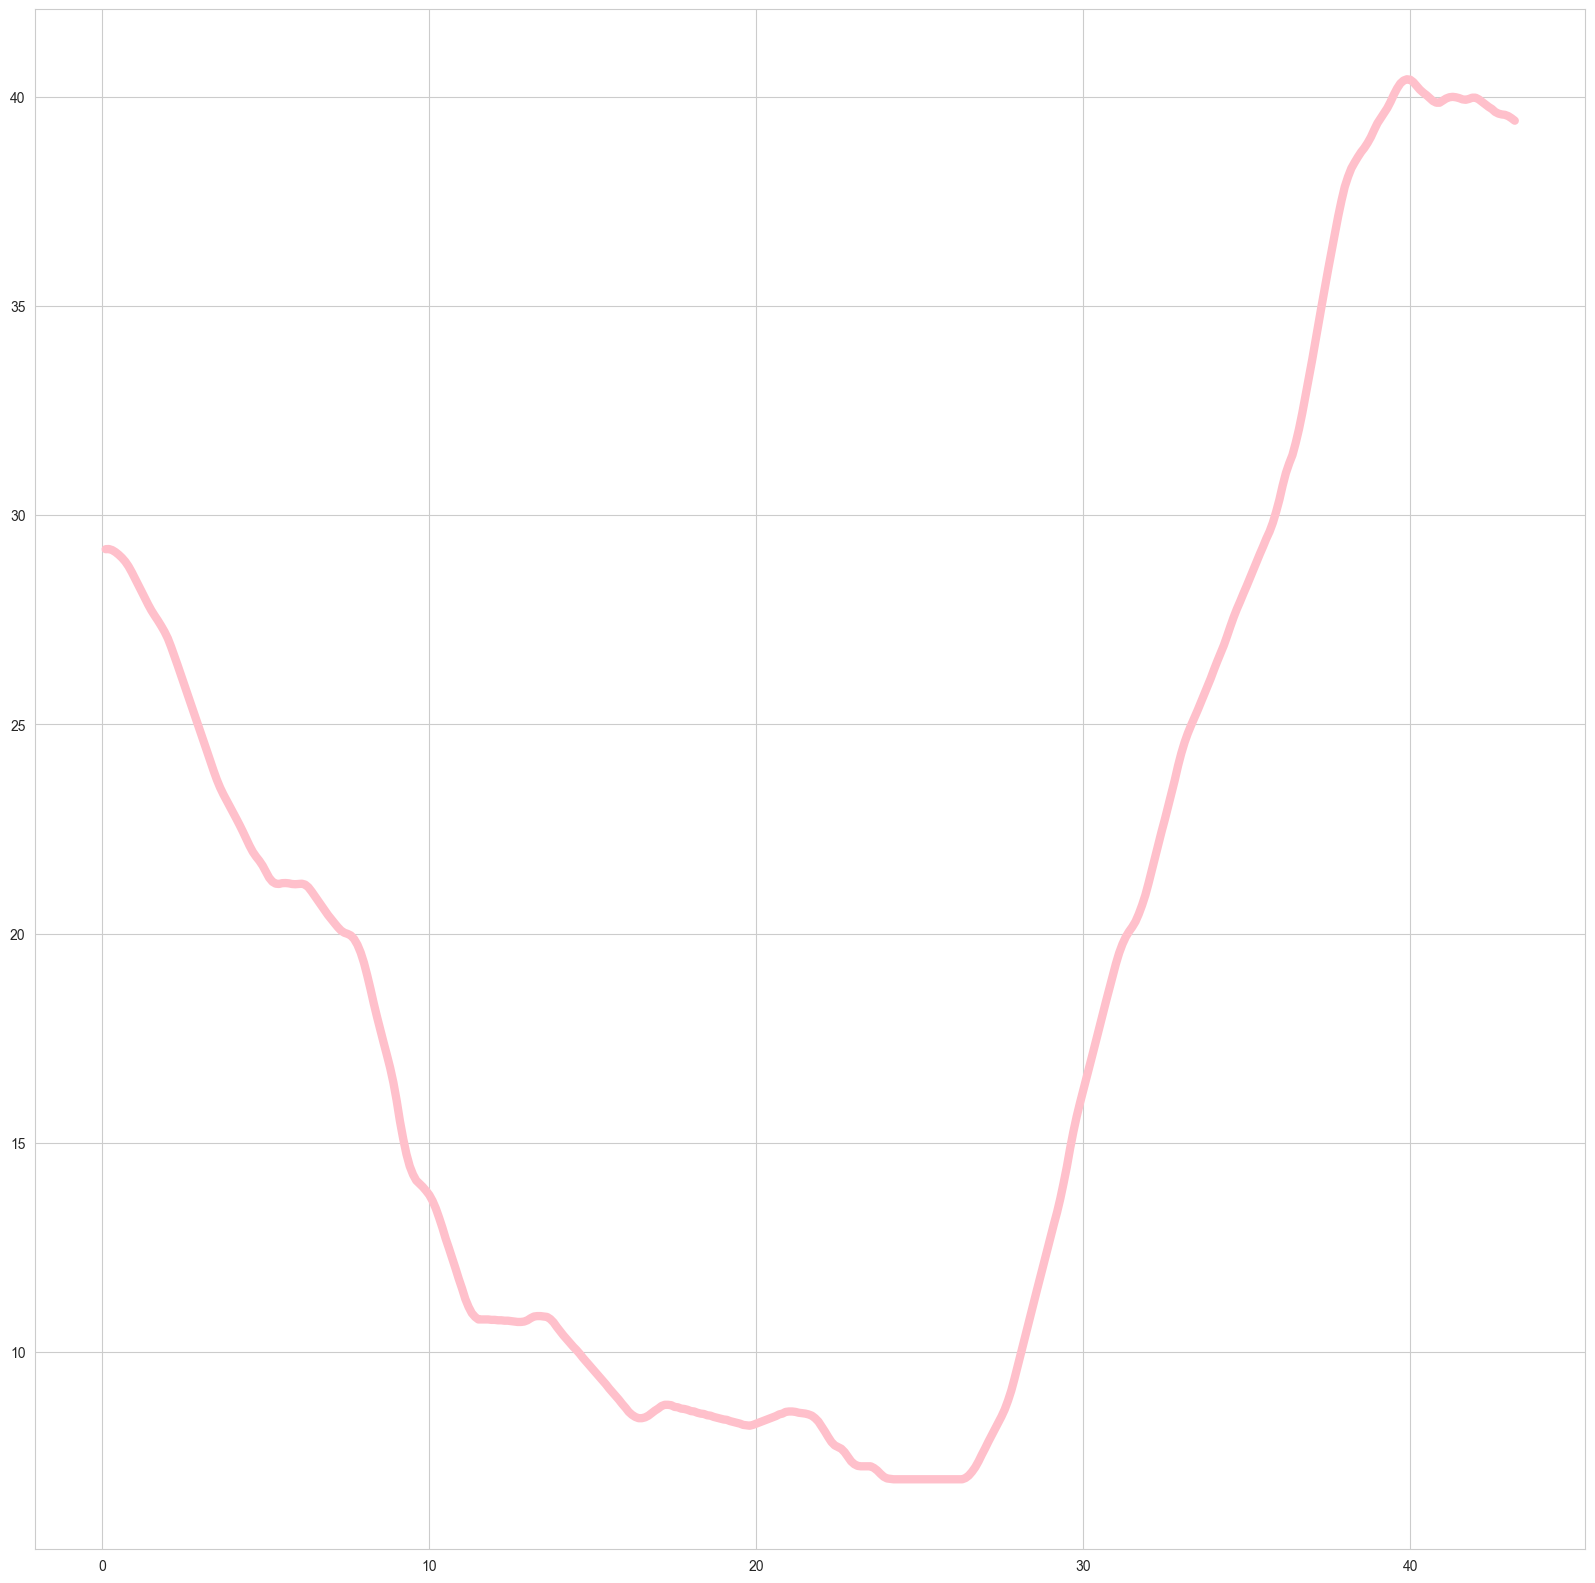

In [45]:
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values

gap_distance

plt.figure(figsize = (20, 20))
plt.plot(data_subset['Time'], gap_distance, color = 'pink', linewidth = 6)

plt.show()

## Comprehensive Vehicle Pair Dashboard

C:\Users\agarc\AppData\Local\Temp\ipykernel_17428\1381152536.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend(fontsize = 20)


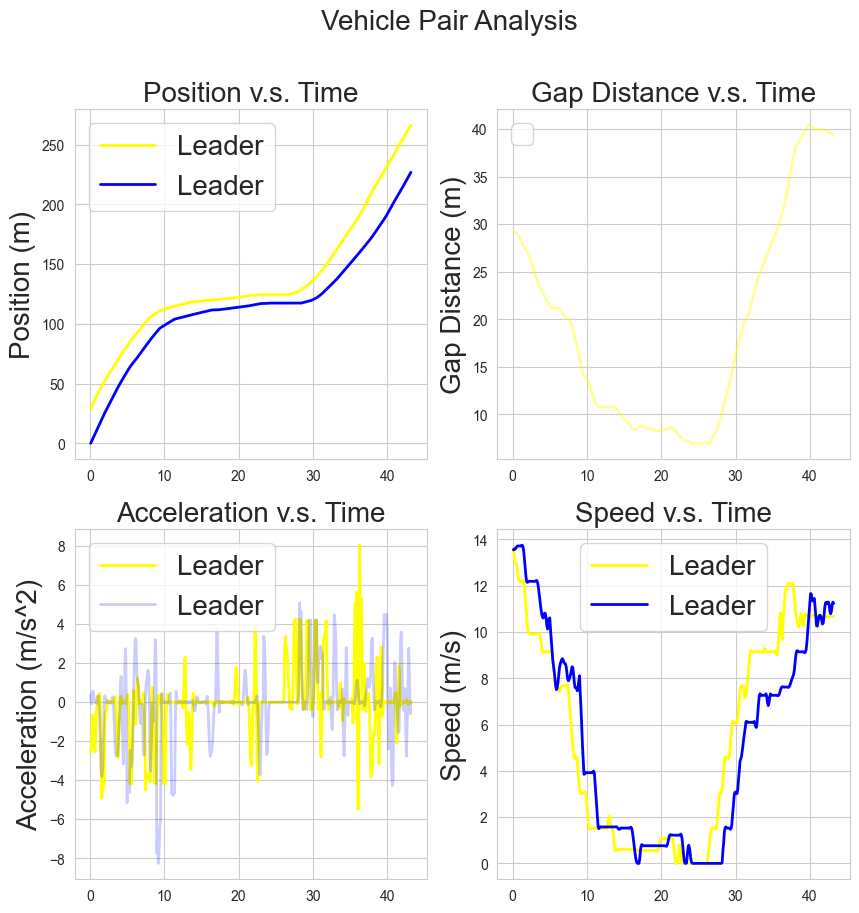

In [61]:
trajectory_number = 10
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time = data_subset['Time'].values

fig, axes = plt.subplots(2,2,figsize=(10,10))

axes[0,0].plot(time, data_subset['leader_position(m)'].values, linewidth = 2, label = 'Leader', color = 'yellow')
axes[0,0].plot(time, data_subset['follower_position(m)'].values, linewidth = 2, label = 'Leader', color = 'blue')
axes[0,0].set_ylabel('Position (m)', fontsize = 20)
axes[0,0].set_title('Position v.s. Time', fontsize = 20)
axes[0,0].legend(fontsize = 20)

axes[1,1].plot(time, data_subset['leader_speed(m/s)'].values, linewidth = 2, label = 'Leader', color = 'yellow')
axes[1,1].plot(time, data_subset['follower_speed(m/s)'].values, linewidth = 2, label = 'Leader', color = 'blue')
axes[1,1].set_ylabel('Speed (m/s)', fontsize = 20)
axes[1,1].set_title('Speed v.s. Time', fontsize = 20)
axes[1,1].legend(fontsize = 20)

axes[1,0].plot(time, data_subset['leader_acc(m/s^2)'].values, linewidth = 2, label = 'Leader', color = 'yellow')
axes[1,0].plot(time, data_subset['follower_acc(m/s^2)'].values, linewidth = 2, label = 'Leader', color = 'blue', alpha = 0.2)
axes[1,0].set_ylabel('Acceleration (m/s^2)', fontsize = 20)
axes[1,0].set_title('Acceleration v.s. Time', fontsize = 20)
axes[1,0].legend(fontsize = 20)

axes[0,1].plot(data_subset['Time'], gap_distance, color = 'yellow', linewidth = 2, alpha = 0.4)
axes[0,1].set_ylabel('Gap Distance (m)', fontsize = 20)
axes[0,1].set_title('Gap Distance v.s. Time', fontsize = 20)
axes[0,1].legend(fontsize = 20)

plt.suptitle('Vehicle Pair Analysis', fontsize = 20)

plt.show()

# Vehicle Trajectory Simulation with IDM

### The IDM Equations

The IDM computes the acceleration of the follower vehicle using the following equation:

$$\frac{dv}{dt} = a \left[1 - \left(\frac{v}{v_0}\right)^{\delta} - \left(\frac{s^*(v, \Delta v)}{s}\right)^2\right]$$

Where $s^*(v, \Delta v)$ is the **desired minimum gap**:

$$s^*(v, \Delta v) = s_0 + v \cdot T + \frac{v \cdot \Delta v}{2\sqrt{a \cdot b}}$$

In [52]:
# The function should take the following inputs:
#   v       : current speed of the follower vehicle (m/s)
#   s       : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0      : desired velocity (m/s)
#   s0      : minimum spacing (m)
#   T       : desired time headway (s)
#   a       : maximum acceleration (m/s^2)
#   b       : comfortable deceleration (m/s^2)
#   delta   : acceleration exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):

    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))

    s_star = max(s_star, s0)

    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)

    return acceleration

## EXAMPLE:

In [53]:
# Test the IDM function with sample values
# A follower traveling at 20 m/s, with a gap of 25 m, approaching the leader at 2 m/s

# Define parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Test case
test_v = 20        # follower speed
test_s = 25        # gap distance
test_delta_v = 2   # follower is faster than leader by 2 m/s

# Call the function and print the result
test_acc = idm_acceleration(test_v, test_s, test_delta_v, v0, s0, T, a, b, delta)
print(f"IDM Acceleration: {test_acc:.4f} m/s^2")

IDM Acceleration: -2.9348 m/s^2


### IT WORKS!!!!

## Setting Up the Simulation

Now that we have our IDM function, we need to simulate a vehicle following scenario over time. To do this, we will use "Euler's method", a simple numerical integration technique you may have seen in your math or physics courses.

The idea is simple: at each small time step *dt*, we update the vehicle's state:

- New acceleration = IDM function output
- New speed = old speed + acceleration × dt
- New position = old position + speed × dt

In [56]:
ngsim_data = pd.read_csv('NGSIM.csv')

trajectory_number = 10
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop = True)

time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

dt = 0.1 # seconds
time_data

array([ 0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,
        1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,  2.2,
        2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,  3.3,
        3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,  4.4,
        4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,  5.5,
        5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,  6.6,
        6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,  7.7,
        7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,  8.8,
        8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,  9.9,
       10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9, 11. ,
       11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. , 12.1,
       12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. , 13.1, 13.2,
       13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14. , 14.1, 14.2, 14.3,
       14.4, 14.5, 14.6, 14.7, 14.8, 14.9, 15. , 15

## Running the IDM Simulation

In [57]:
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0   # maximum acceleration (m/s^2)
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

n_steps = len(time_data)               
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acc = np.zeros(n_steps)

sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]

for i in range(n_steps - 1):

    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]

    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)

    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i]*dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i]*dt

print("Simulation complete!")

Simulation complete!


## Visualizing the Results from the Simulation

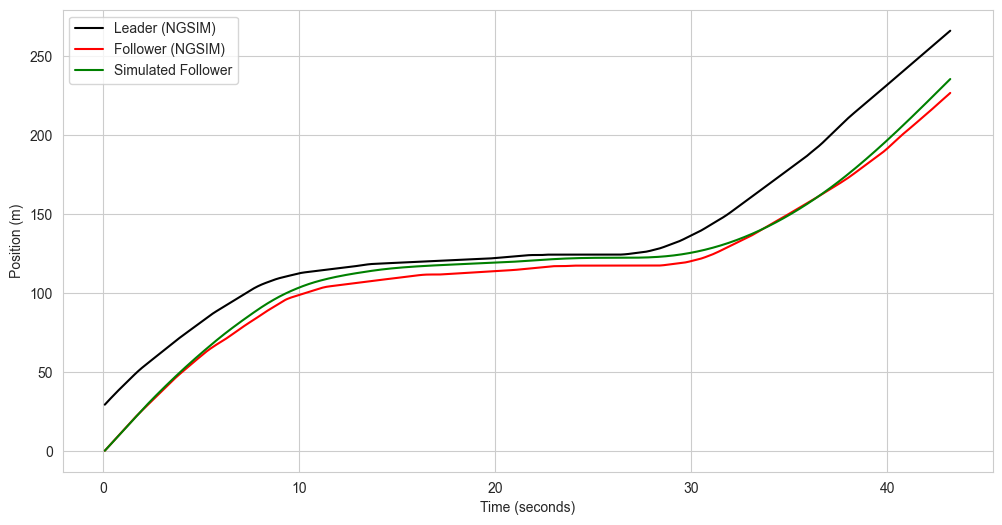

In [58]:
plt.figure(figsize = (12,6))
plt.plot(time_data, leader_position, label = 'Leader (NGSIM)', color = "black")
plt.plot(time_data, data_subset['follower_position(m)'].values, label = 'Follower (NGSIM) ', color = "red")
plt.plot(time_data, sim_position, label = 'Simulated Follower', color = "green")
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True, alpha = 1)
plt.show()

## Speed Comparison

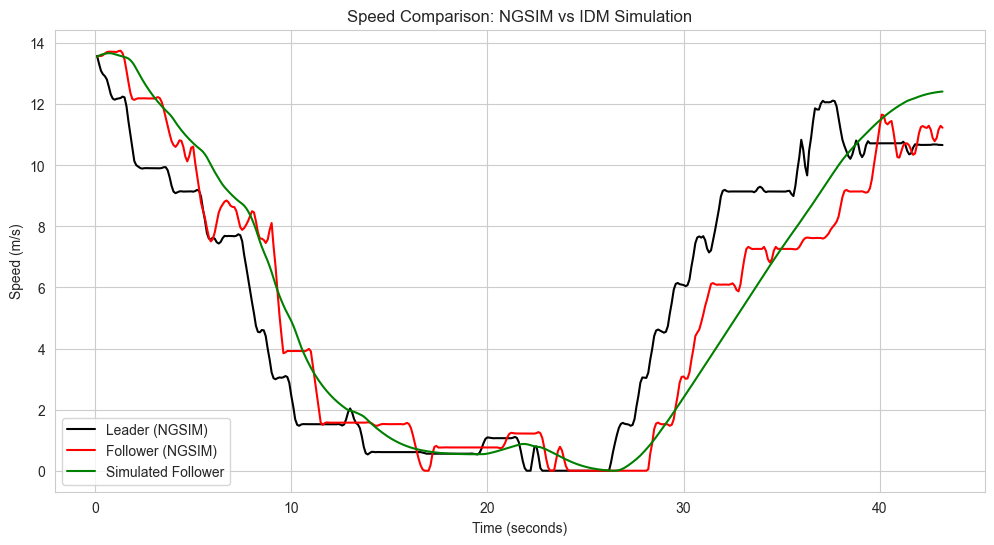

In [59]:
plt.figure(figsize = (12,6))
plt.plot(time_data, leader_speed, label = 'Leader (NGSIM)', color = "black")
plt.plot(time_data, data_subset['follower_speed(m/s)'].values, label = 'Follower (NGSIM)', color = "red")
plt.plot(time_data, sim_speed, label = 'Simulated Follower', color = "green")
plt.xlabel('Time (seconds)')
plt.ylabel('Speed (m/s)')
plt.title('Speed Comparison: NGSIM vs IDM Simulation')
plt.legend()
plt.grid(True, alpha = 1)
plt.show()

## Acceleration Comparison


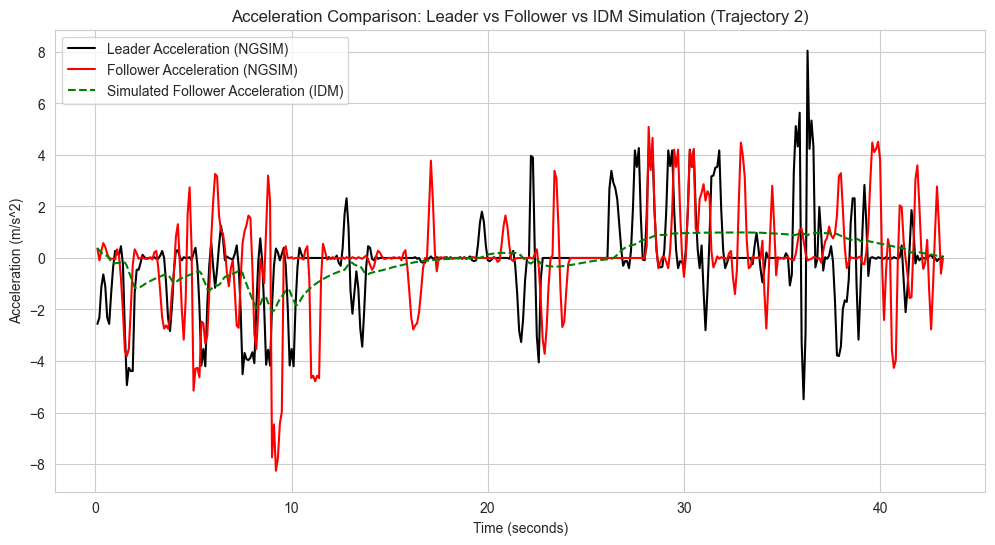

In [60]:
gap = max(leader_position[-1] - sim_position[-1], 0.1)
delta_v = sim_speed[-1] - leader_speed[-1]
sim_acc[-1] = idm_acceleration(sim_speed[-1], gap, delta_v, v0, s0, T, a_param, b, delta)

plt.figure(figsize = (12,6))
plt.plot(time_data, data_subset['leader_acc(m/s^2)'].values, label = 'Leader Acceleration (NGSIM)', color = "black")
plt.plot(time_data, data_subset['follower_acc(m/s^2)'].values, label = 'Follower Acceleration (NGSIM)', color = "red")
plt.plot(time_data, sim_acc, label = 'Simulated Follower Acceleration (IDM)', color = "green", linestyle = '--')
plt.xlabel('Time (seconds)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Acceleration Comparison: Leader vs Follower vs IDM Simulation (Trajectory 2)')
plt.legend()
plt.grid(True, alpha = 1)
plt.show()